# Potts models for protein sequences: a hands-on tutorial (plmDCA & bmDCA)

This notebook is a from-scratch introduction to **Direct Coupling Analysis (DCA)**
— fitting a Potts model to a protein multiple sequence alignment (MSA). No prior
exposure is assumed. We build the intuition, then the two workhorse inference
methods (**plmDCA** and **bmDCA**), fit both on the *same* alignment, and compare
what they learn: the single-site fields, the pairwise couplings, how well each
reproduces the data's two- and three-point statistics, and how well each predicts
real structural contacts.

We go: the data → why a Potts model (max-entropy; direct vs. indirect correlation)
→ why inference is hard (the partition function) → **plmDCA** → **bmDCA** → fit both
→ compare → tradeoffs.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

import jaxpotts as jp
from jaxpotts import bm, gauge

try:
    get_ipython().run_line_magic("matplotlib", "inline")  # noqa: F821
except Exception:
    pass

# A small, colorblind-safe palette (Okabe-Ito), assigned by *identity* and reused
# everywhere: the data is neutral grey, plmDCA blue, bmDCA vermillion.
C = {"data": "#4d4d4d", "plm": "#0072B2", "bm": "#D55E00", "grid": "#d9d9d9"}
SEQ = "cividis"          # sequential (magnitude): one hue, light->dark, CVD-safe
DIV = "RdBu_r"           # diverging (signed difference): two hues + neutral middle
plt.rcParams.update({"axes.grid": True, "grid.color": C["grid"], "grid.linewidth": 0.6,
                     "axes.axisbelow": True, "figure.dpi": 110, "font.size": 10})

## 1. The data: a protein multiple sequence alignment

A protein is a chain of amino acids. Over evolution, a protein family accumulates
many **homologs** — variants in different organisms that fold the same way and do
the same job. Line those homologs up column-by-column and you get a **multiple
sequence alignment (MSA)**: a matrix where every **row is one protein** and every
**column is one position** in the shared structure. Each cell is one of 20 amino
acids or a gap (`-`).

We use `1atzA` (3068 sequences, 75 columns), the example family shipped with
CCMpred.

In [2]:
A = jp.read_msa("data/1atzA.aln")     # (N, L) int8; states 0..19 = amino acids, 20 = gap
N, L = A.shape
q = 21
print(f"MSA: N = {N} sequences, L = {L} columns, q = {q} states "
      f"(20 amino acids + gap)")
print("first sequence:", jp.io.decode_sequence(A[0]))

MSA: N = 3068 sequences, L = 75 columns, q = 21 states (20 amino acids + gap)
first sequence: -AADIVFLVDGSINLGRNNFKEVMEFILNLIDLFYTERDRLQIGLAHYATDVTDVFYLNTYNNKDDIINAIT---


Two things jump out of any MSA. **Some columns are conserved** — nearly always the
same amino acid — because that residue is essential (its identity is under
selection). And **some pairs of columns vary together** — a mutation at one
position is compensated by a mutation at another. That second effect,
**coevolution**, is the signal DCA is built to exploit: positions that coevolve are
often in physical contact in the folded structure, or otherwise functionally
coupled.

effective # sequences N_eff = 1189 (reweighting near-duplicates)


/tmp/ipykernel_930066/646428489.py:10: RuntimeWarning: divide by zero encountered in log
  ent = -np.sum(np.where(p > 0, p * np.log(p), 0.0), axis=1)
/tmp/ipykernel_930066/646428489.py:10: RuntimeWarning: invalid value encountered in multiply
  ent = -np.sum(np.where(p > 0, p * np.log(p), 0.0), axis=1)


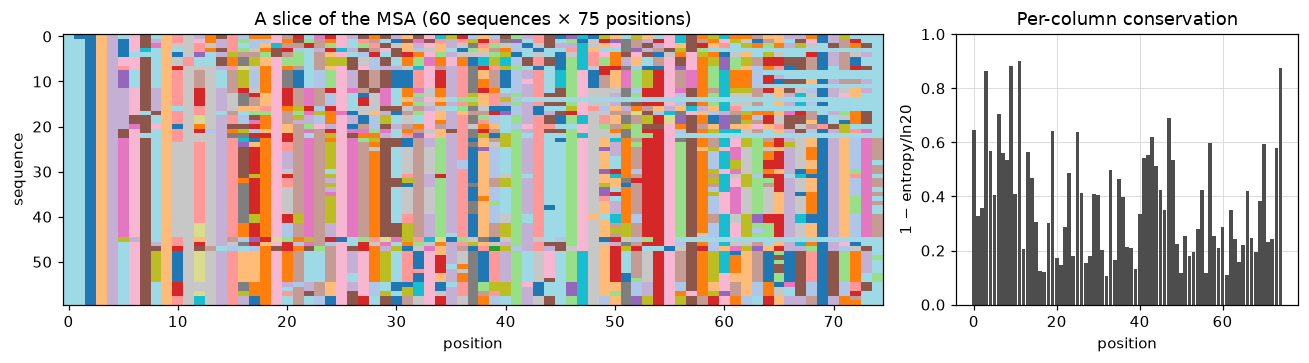

In [3]:
X = jax.nn.one_hot(jnp.asarray(A), q)          # (N, L, q) one-hot
w = jp.sequence_weights(A, cutoff=0.8)         # down-weight near-duplicate homologs
w_j = jnp.asarray(w)
f1 = np.asarray(bm.one_point_freqs(X, w_j))    # (L, q) single-site frequencies
neff = float(w.sum())
print(f"effective # sequences N_eff = {neff:.0f} (reweighting near-duplicates)")

# Per-column conservation = 1 - entropy/log(20), over amino acids only.
p = f1[:, :20] / f1[:, :20].sum(1, keepdims=True)
ent = -np.sum(np.where(p > 0, p * np.log(p), 0.0), axis=1)
conservation = 1 - ent / np.log(20)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={"width_ratios": [2.4, 1]})
# (a) a slice of the alignment as an image: rows = sequences, cols = positions.
axes[0].imshow(A[:60, :], aspect="auto", cmap="tab20", interpolation="nearest")
axes[0].set_title("A slice of the MSA (60 sequences × 75 positions)")
axes[0].set_xlabel("position"); axes[0].set_ylabel("sequence"); axes[0].grid(False)
# (b) per-column conservation.
axes[1].bar(np.arange(L), conservation, color=C["data"], width=0.9)
axes[1].set_title("Per-column conservation")
axes[1].set_xlabel("position"); axes[1].set_ylabel("1 − entropy/ln20"); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

To *see* coevolution directly, take the pair of columns whose amino-acid usage is
most statistically dependent (highest **mutual information**) and lay their joint
frequency table next to the table we would expect if the two columns varied
**independently** — the outer product of their two single-column profiles,
$f_i(a)\,f_j(b)$. We keep only the amino acids that actually occur at each column, so
the tables are small and readable, and print each cell as a percentage. The three
panels are:

1. **observed** — how often each pair (`a` at column *i*, `b` at column *j*) really
   co-occurs across the alignment;
2. **if independent** — the same table rebuilt from the two columns' profiles alone,
   pretending they don't influence each other;
3. **observed − independent** — the difference. **Red** cells occur *more* often than
   independence predicts, **blue** cells *less* often. A non-zero difference panel is
   coevolution — precisely the signal the Potts couplings will learn.

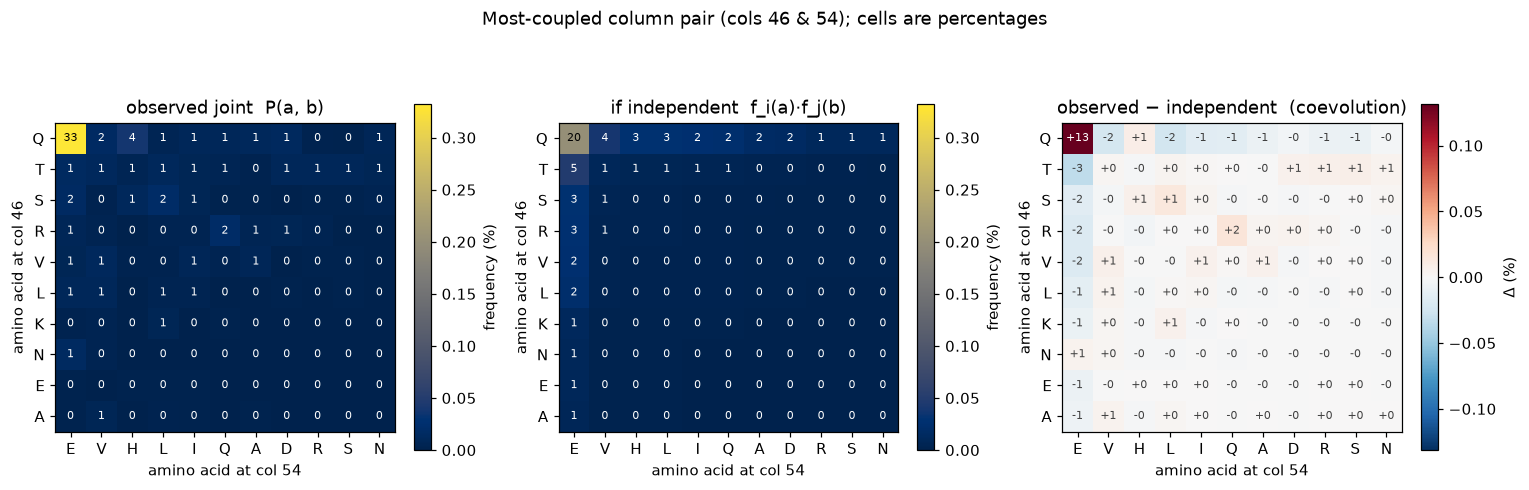

In [4]:
f2 = np.asarray(bm.two_point_freqs(X, w_j))    # (L, q, L, q) pairwise frequencies
# Mutual information per column pair (amino acids only), diagonal removed.
fa = f1[:, None, :20, None]
fb = f1[None, :, None, :20]
fab = f2[:, :20, :, :20].transpose(0, 2, 1, 3)  # (L, L, 20, 20) as [i,j,a,b]
mi = np.sum(np.where(fab > 0, fab * np.log((fab + 1e-12) / (fa * fb + 1e-12)), 0.0), axis=(2, 3))
np.fill_diagonal(mi, 0.0)
i0, j0 = np.unravel_index(np.argmax(mi), mi.shape)
AA = "ARNDCQEGHILKMFPSTWYV"

# Keep only the amino acids that actually appear (>2%) at each column, most common first,
# so the 20x20 table collapses to a small, legible block instead of a sea of zeros.
fi, fj = f1[i0, :20], f1[j0, :20]
ai = np.where(fi > 0.02)[0][np.argsort(-fi[np.where(fi > 0.02)])]
aj = np.where(fj > 0.02)[0][np.argsort(-fj[np.where(fj > 0.02)])]
labi, labj = [AA[a] for a in ai], [AA[a] for a in aj]

joint = fab[i0, j0][np.ix_(ai, aj)]        # observed P(a at col i0, b at col j0)
indep = np.outer(fi[ai], fj[aj])           # what independence predicts (outer product)
diff = joint - indep                       # the departure = coevolution


def _table(ax, M, cmap, vmin, vmax, title, diverging=False):
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
    ax.set_xticks(range(len(labj))); ax.set_xticklabels(labj)
    ax.set_yticks(range(len(labi))); ax.set_yticklabels(labi)
    ax.set_xlabel(f"amino acid at col {j0}"); ax.set_ylabel(f"amino acid at col {i0}")
    ax.set_title(title); ax.grid(False)
    span = vmax if not diverging else vmax
    for r in range(M.shape[0]):
        for c in range(M.shape[1]):
            v = M[r, c]
            if diverging:
                tc = "white" if abs(v) > 0.6 * span else "0.25"
                txt = f"{100 * v:+.0f}"
            else:
                tc = "white" if v < 0.5 * span else "black"
                txt = f"{100 * v:.0f}"
            ax.text(c, r, txt, ha="center", va="center", fontsize=7, color=tc)
    plt.colorbar(im, ax=ax, fraction=0.046, label="frequency (%)" if not diverging else "Δ (%)")


fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
vmax_j = max(joint.max(), indep.max())          # shared scale so the two are comparable
vmax_d = np.abs(diff).max()
_table(axes[0], joint, SEQ, 0, vmax_j, "observed joint  P(a, b)")
_table(axes[1], indep, SEQ, 0, vmax_j, "if independent  f_i(a)·f_j(b)")
_table(axes[2], diff, DIV, -vmax_d, vmax_d, "observed − independent  (coevolution)", diverging=True)
fig.suptitle(f"Most-coupled column pair (cols {i0} & {j0}); cells are percentages", y=1.02)
plt.tight_layout(); plt.show()

## 2. Why a Potts model? The maximum-entropy argument

We want a probability distribution over whole sequences, `P(x₁, x₂, …, x_L)`, that
captures this family. But which distribution? There are infinitely many that could
reproduce what we measured. The **maximum-entropy principle** picks the honest one:
among all distributions that reproduce the statistics we trust, choose the one that
is otherwise **as unstructured (high-entropy) as possible** — assuming nothing we
didn't measure.

If the statistics we trust are the **single-site frequencies** `f_i(a)` (how often
amino acid `a` appears at position `i`) and the **pairwise frequencies**
`f_ij(a,b)` (how often `a` and `b` co-occur at positions `i,j`), then the
maximum-entropy solution has exactly one form — the **Potts model**:

$$P(x) \;\propto\; \exp\!\Big(\textstyle\sum_i h_i(x_i) \;+\; \sum_{i<j} J_{ij}(x_i,x_j)\Big)
  \;=\; \exp(-E(x)).$$

The parameters are the Lagrange multipliers that enforce the matching:

- **Fields** `h_i(a)` — a per-position preference for each amino acid. They capture
  **conservation** (a strongly conserved column has a large field for its favored
  residue).
- **Couplings** `J_ij(a,b)` — a preference for *pairs* of amino acids at two
  positions. They capture **coevolution / epistasis**: the direct statistical
  interaction between two positions.

So a Potts model isn't an arbitrary choice — it is *the* least-assumption
distribution consistent with the one- and two-body statistics of the MSA. Fitting
it means finding the `h` and `J` that make the model's marginals match the data's.

### Direct vs. indirect correlation — the whole point of "Direct" Coupling Analysis

Why bother inferring `J` at all — why not just use the measured correlations (or
mutual information) to call contacts? Because **correlation is transitive**. If
position `i` is coupled to `j`, and `j` to `k`, then `i` and `k` will *look*
correlated even if they never touch — the signal passes through `j`. Raw
correlation maps are blurred by these **indirect** chains. The coupling `J_ij` is
the **direct** interaction, with the transitive paths "explained away" — which is
why it is so much cleaner for predicting physical contacts. Here is the raw
mutual-information map; keep it in mind, and compare it in §7 to the coupling map
the models infer.

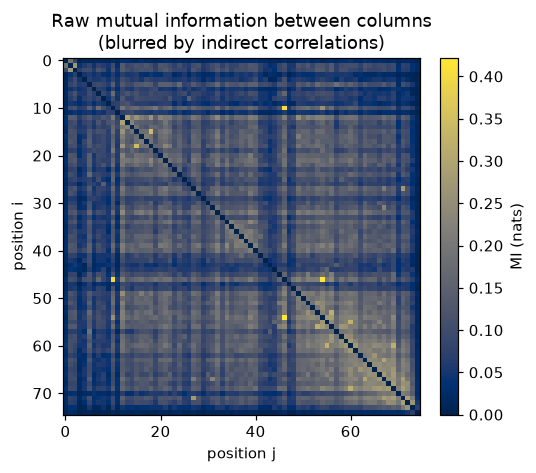

In [5]:
fig, ax = plt.subplots(figsize=(5, 4.4))
im = ax.imshow(mi, cmap=SEQ, interpolation="nearest")
ax.set_title("Raw mutual information between columns\n(blurred by indirect correlations)")
ax.set_xlabel("position j"); ax.set_ylabel("position i"); ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046, label="MI (nats)")
plt.tight_layout(); plt.show()

## 3. The catch: the partition function is intractable

The Potts probability has a normaliser, the **partition function**
`Z = Σ_x exp(-E(x))`, summed over **every possible sequence**. For our small family
that is `21⁷⁵ ≈ 10⁹⁹` sequences — more than atoms in the universe. We can never
compute `Z`, the exact likelihood, or its exact gradient.

Every DCA method is therefore a way to *dodge* `Z`. The two dominant strategies —
and the subject of this notebook — are:

- **plmDCA**: replace the likelihood with a surrogate (the *pseudo*-likelihood)
  that never needs `Z`. Fast and convex, but approximate.
- **bmDCA**: keep the true likelihood, but estimate the intractable term by
  **sampling** from the model (MCMC). Exact in principle, but expensive.

## 4. plmDCA — pseudo-likelihood, step by step

The trick: while the *joint* `P(x)` needs `Z`, the **conditional** distribution of
one column given all the others does not. Given every position except `i`, the
probability that position `i` is amino acid `a` is a simple **softmax**:

$$P(x_i = a \mid x_{\setminus i}) \;=\;
  \frac{\exp\!\big(h_i(a) + \sum_{j\neq i} J_{ij}(a, x_j)\big)}
       {\sum_{b} \exp\!\big(h_i(b) + \sum_{j\neq i} J_{ij}(b, x_j)\big)}.$$

The normaliser here is a sum over just **21 states**, not 21⁷⁵ — completely
tractable. The **pseudo-likelihood** approximates the joint log-likelihood by the
sum of these per-column conditional log-likelihoods, over every column of every
(reweighted) sequence, plus an L2 penalty on `h` and `J` to tame overfitting:

$$\mathcal{L}_{\text{plm}} \;=\; \sum_n w_n \sum_i \log P\!\big(x_i^{n} \mid x_{\setminus i}^{n}\big)
  \;-\; \lambda_h \lVert h\rVert^2 - \lambda_J \lVert J\rVert^2.$$

**How it works, operationally:** each column `i` is treated as a multiclass logistic
regression that predicts its own residue from all the other columns, and all these
regressions *share* one symmetric coupling tensor `J`. We maximise the total with a
convex optimizer (L-BFGS). One forward/backward pass touches the whole MSA at once.

**Tradeoffs.** Fast, **convex** (one global optimum), statistically *consistent*,
and excellent at **ranking contacts**. But it optimises a *surrogate*: the fitted
model is **not guaranteed to reproduce** the pairwise frequencies it was trained on,
so it is not a faithful generative model (§7 shows this concretely). Full tradeoff
table in §8.

## 5. bmDCA — Boltzmann-machine learning, step by step

bmDCA refuses the surrogate and maximises the **true** log-likelihood by gradient
ascent. The gradient of the Potts log-likelihood has a remarkably clean form:

$$\frac{\partial \mathcal{L}}{\partial J_{ij}(a,b)} \;=\;
  \underbrace{f_{ij}(a,b)}_{\text{data}} \;-\; \underbrace{p_{ij}(a,b)}_{\text{model}},
  \qquad
  \frac{\partial \mathcal{L}}{\partial h_i(a)} \;=\; f_i(a) - p_i(a).$$

In words: **"move the parameters so the model's marginals match the data's
marginals."** At the maximum, the two-point frequencies of the model equal those of
the data — the model *reproduces the correlations by construction*.

The catch is the model term `p_ij(a,b)` — it needs `Z`. bmDCA estimates it by
**Gibbs sampling**: keep a population of "fantasy" sequences (Markov chains),
repeatedly resample one column at a time from its conditional (the same softmax as
above), and read the model marginals off the samples. Each training step is:

1. **Sample**: run a Gibbs sweep over the persistent chains under the current `h, J`.
2. **Estimate**: compute `p_i(a)` and `p_ij(a,b)` from the fantasy sequences.
3. **Update**: nudge `h, J` by `(data − model)` (gradient ascent), with L2.

Reusing the same chains across steps is **persistent contrastive divergence (PCD)**
— the chains stay near equilibrium as the parameters drift slowly, so a single
sweep per step suffices.

**Tradeoffs.** A genuine **generative model** — it reproduces the two-point (and, as
we test in §7, much of the three-point) statistics, and can sample realistic new
sequences. The price: it is **expensive and stochastic** (MCMC every step, thousands
of iterations, more knobs — chains, sweeps, learning-rate schedule). Note the
objective is *still convex* — `log Z` is convex — but its gradient's model term is a
**noisy MCMC estimate**, so training is a stochastic wander rather than the clean
descent plmDCA enjoys. Full tradeoff table in §8.

## 6. Fit both models on the same MSA

We fit plmDCA and bmDCA on `1atzA` with the **same regularisation strengths**
(`λ_single = 0.01`, `λ_pair ∝ 0.2·(L-1)`), and let bmDCA learn its fields too
(`fix_v=False`) so we can compare them. plmDCA converges its convex objective in a
few hundred L-BFGS iterations; bmDCA needs of order a thousand PCD steps, and we
watch it *learn to reproduce the data's two-point correlations* as it trains.

In [6]:
plm_params, plm_info = jp.plm.fit(
    A, weights=w, lambda_single=0.01, lambda_pair_factor=0.2, method="lbfgs",
    maxiter=1000, tol=1e-9)
J_plm = np.asarray(jp.couplings(plm_params.W), np.float64)
h_plm = np.asarray(plm_params.h, np.float64)
print(f"plmDCA: converged in {plm_info['n_iter']} L-BFGS iterations")

bm_params, bm_info = jp.bm.fit(
    A, weights=w, n_chains=2000, gibbs_steps=1, alpha0=1e-3,
    lambda_single=0.01, lambda_pair_factor=0.2,      # same reg strengths as plmDCA above
    maxiter=2500, epsilon=1e-8, persistent=True, fix_v=False, seed=0, record_every=100)
J_bm = np.asarray(bm_params.W, np.float64)
h_bm = np.asarray(bm_params.h, np.float64)
print(f"bmDCA:  ran {bm_info['n_iter']} PCD steps; "
      f"final two-point correlation fit = {bm_info['final_corr']:.3f}")

plmDCA: converged in 286 L-BFGS iterations


bmDCA:  ran 1602 PCD steps; final two-point correlation fit = 0.811


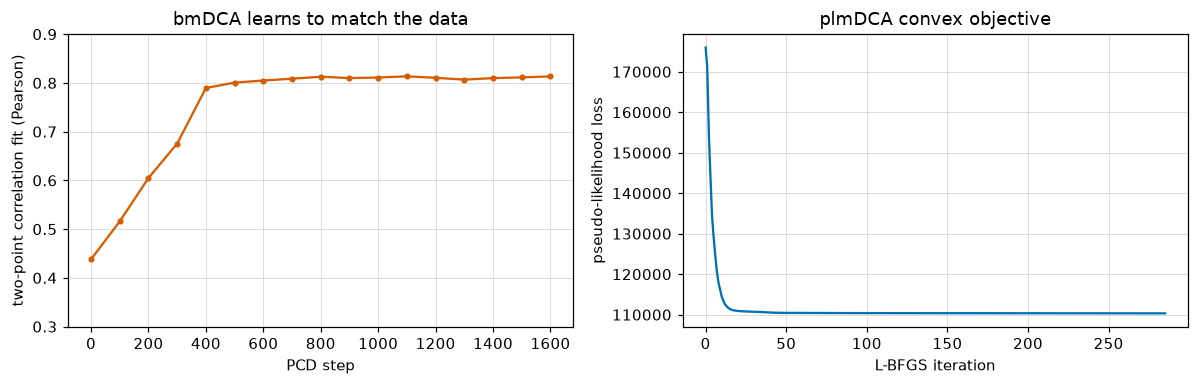

In [7]:
# Training progress: bmDCA's two-point-correlation fit climbing vs plmDCA's convex loss.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
curve = [(r["iter"], r["corr"]) for r in bm_info["curve"] if "corr" in r]
it, corr = zip(*curve)
axes[0].plot(it, corr, "-o", color=C["bm"], ms=3)
axes[0].set_title("bmDCA learns to match the data")
axes[0].set_xlabel("PCD step"); axes[0].set_ylabel("two-point correlation fit (Pearson)")
axes[0].set_ylim(0.3, 0.9)
axes[1].plot(plm_info["history"], "-", color=C["plm"])
axes[1].set_title("plmDCA convex objective")
axes[1].set_xlabel("L-BFGS iteration"); axes[1].set_ylabel("pseudo-likelihood loss")
plt.tight_layout(); plt.show()

## 7. What did they learn? Comparing fields, couplings, and correlations

To compare two Potts models we must fix the **gauge** — the couplings have a
built-in redundancy (you can shift `J` and compensate in `h` without changing any
probability). We map both to the standard **zero-sum gauge**, then compare. To
judge each as a *generative* model we also **sample** from it (Gibbs) and measure
how well the samples' statistics match the data's — over amino acids only, so the
(frozen) gaps don't flatter the comparison.

In [8]:
# Zero-sum gauge for parameter comparison.
hz_plm, Jz_plm = (np.asarray(a) for a in gauge.zero_sum_gauge(h_plm, J_plm))
hz_bm, Jz_bm = (np.asarray(a) for a in gauge.zero_sum_gauge(h_bm, J_bm))

# Sample each model, then compute empirical statistics (amino acids 0..19 only).
def sample_model(h, J, n=8000, sweeps=100, seed=0):
    idx = np.random.default_rng(seed).integers(0, N, n)
    S0 = jnp.asarray(A[idx].astype(np.int32))
    Sm = bm.sample_chains(jr.key(seed), S0, jnp.asarray(h, jnp.float32),
                          jnp.asarray(J, jnp.float32), sweeps, 20, (S0 == 20))
    return np.asarray(Sm)

def marg12(Aint, weights=None):
    Xf = jax.nn.one_hot(jnp.asarray(Aint), q)
    wj = jnp.ones(Aint.shape[0]) if weights is None else jnp.asarray(weights)
    return np.asarray(bm.one_point_freqs(Xf, wj)), np.asarray(bm.two_point_freqs(Xf, wj))

S_plm = sample_model(h_plm, J_plm, seed=1)
S_bm = sample_model(h_bm, J_bm, seed=2)
f1_data, f2_data = marg12(A, w)
f1_plm, f2_plm = marg12(S_plm)
f1_bm, f2_bm = marg12(S_bm)

# APC-corrected contact scores (zero-sum gauge -> Frobenius over amino acids -> APC),
# the standard DCA contact predictor.
def score_map(h, J):
    return np.asarray(gauge.contact_score(jnp.asarray(h), jnp.asarray(J),
                                          include_gap=False, apply_apc=True))
S_plm_map = score_map(h_plm, J_plm)
S_bm_map = score_map(h_bm, J_bm)

# Ground-truth residue contacts from the crystal structure (C-beta < 8 Å, |i-j| >= 5).
# MSA column i corresponds to PDB residue i+1.
def true_contacts(pdb, L, cutoff=8.0, sep=5):
    coord = np.full((L, 3), np.nan)
    for ln in open(pdb):
        if ln.startswith("ATOM"):
            atom, res = ln[12:16].strip(), int(ln[22:26])
            if 1 <= res <= L and (atom == "CB" or (atom == "CA" and np.isnan(coord[res - 1, 0]))):
                coord[res - 1] = (float(ln[30:38]), float(ln[38:46]), float(ln[46:54]))
    d = np.sqrt(((coord[:, None, :] - coord[None, :, :]) ** 2).sum(-1))
    far = np.abs(np.subtract.outer(np.arange(L), np.arange(L))) >= sep
    return (d < cutoff) & far

contacts = true_contacts("data/1atzA.pdb", L)
print(f"ground-truth contacts (|i-j|>=5, Cβ<8Å): {int(np.triu(contacts).sum())}")

ground-truth contacts (|i-j|>=5, Cβ<8Å): 127


### 7a. Single-site terms

The **fields** `h_i(a)` encode conservation, and with matched regularisation the two
methods largely agree on them (left; the spread reflects that they are different
estimators). The **single-site frequencies** are the easy part: bmDCA reproduces
them *by construction* (its gradient is literally `f_i(a) − p_i(a)`), and plmDCA
reproduces them well in practice too (right). The interesting differences are all in
the *pairwise* terms.

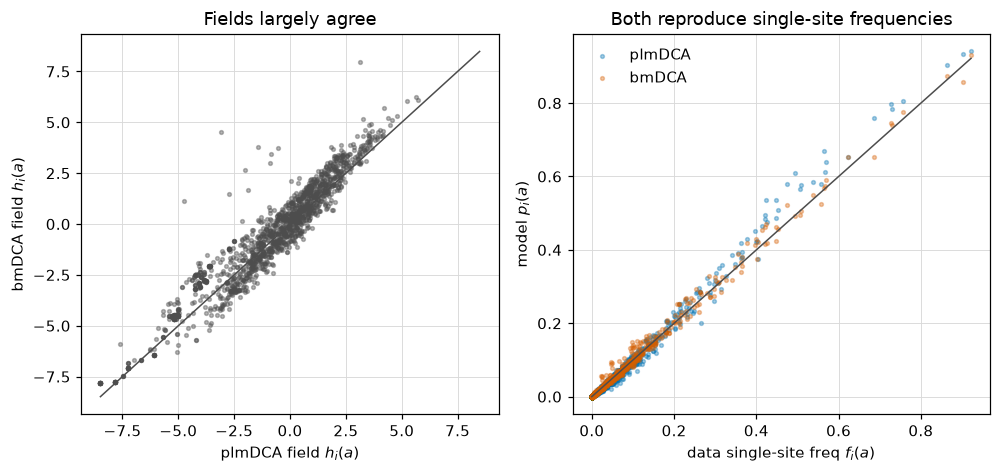

In [9]:
iu = np.triu_indices(L, k=1)
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.4))
axes[0].scatter(hz_plm[:, :20].ravel(), hz_bm[:, :20].ravel(), s=6, alpha=0.4, color=C["data"])
lim = np.abs(np.concatenate([hz_plm[:, :20].ravel(), hz_bm[:, :20].ravel()])).max()
axes[0].plot([-lim, lim], [-lim, lim], color=C["data"], lw=1)
axes[0].set_xlabel("plmDCA field $h_i(a)$"); axes[0].set_ylabel("bmDCA field $h_i(a)$")
axes[0].set_title("Fields largely agree")
for f1m, lbl, col in [(f1_plm, "plmDCA", C["plm"]), (f1_bm, "bmDCA", C["bm"])]:
    axes[1].scatter(f1_data[:, :20].ravel(), f1m[:, :20].ravel(), s=6, alpha=0.35,
                    color=col, label=lbl)
axes[1].plot([0, f1_data[:, :20].max()], [0, f1_data[:, :20].max()], color=C["data"], lw=1)
axes[1].set_xlabel("data single-site freq $f_i(a)$"); axes[1].set_ylabel("model $p_i(a)$")
axes[1].set_title("Both reproduce single-site frequencies"); axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

### 7b. Couplings, contacts, and the payoff

The **coupling values** are strongly correlated between the two methods (left) —
they largely agree on *which* pairs interact — though not identical, since plmDCA
and bmDCA are different estimators that shrink couplings differently. What matters
for structure is the **contact map**: the per-pair coupling strength `‖J_ij‖`,
zero-sum-gauged and APC-corrected (the standard DCA score). Both methods give nearly
the same map, and the strongest predictions land squarely on the **true contacts**
from the crystal structure (red circles).

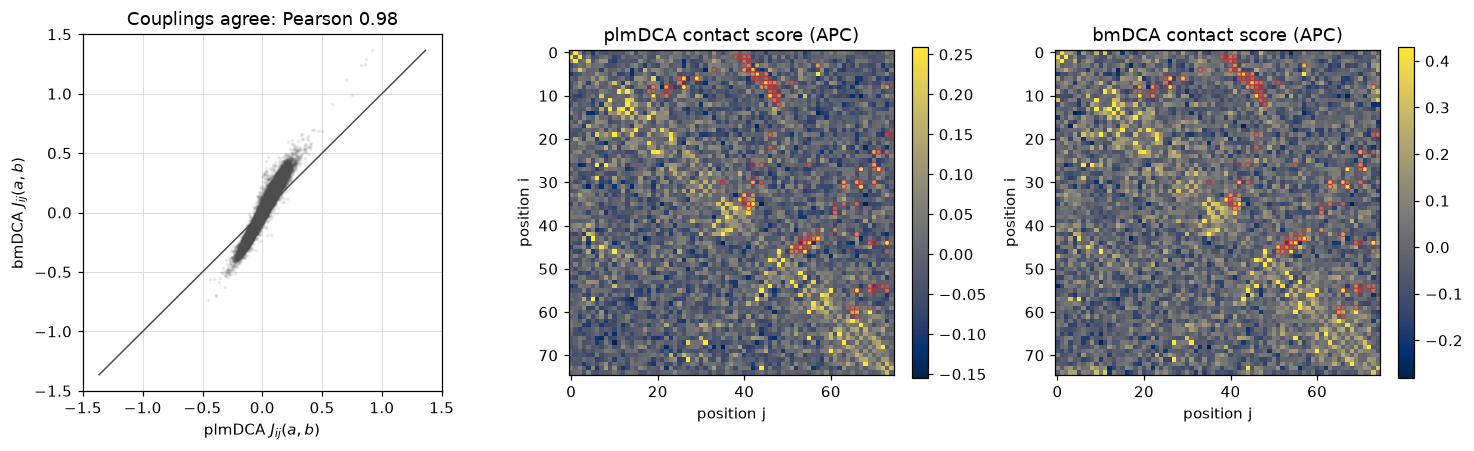

In [10]:
from scipy.stats import pearsonr

def coupling_vec(Jz):                    # off-diagonal (i<j) blocks, amino acids
    return Jz.transpose(0, 2, 1, 3)[iu][:, :20, :20].ravel()

cv_plm, cv_bm = coupling_vec(Jz_plm), coupling_vec(Jz_bm)
ti, tj = np.where(np.triu(contacts, 1))   # true-contact pairs, for overlay

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
axes[0].scatter(cv_plm, cv_bm, s=2, alpha=0.08, color=C["data"], rasterized=True)
lim = max(np.abs(cv_plm).max(), np.abs(cv_bm).max())
axes[0].plot([-lim, lim], [-lim, lim], color=C["data"], lw=1)
axes[0].set_xlabel("plmDCA $J_{ij}(a,b)$"); axes[0].set_ylabel("bmDCA $J_{ij}(a,b)$")
axes[0].set_title(f"Couplings agree: Pearson {pearsonr(cv_plm, cv_bm)[0]:.2f}")
for ax, S, lbl in [(axes[1], S_plm_map, "plmDCA"), (axes[2], S_bm_map, "bmDCA")]:
    im = ax.imshow(S, cmap=SEQ, vmax=np.percentile(S, 99), interpolation="nearest")
    ax.scatter(tj, ti, s=10, facecolors="none", edgecolors="#d62728", linewidths=0.5)
    ax.set_title(f"{lbl} contact score (APC)"); ax.grid(False)
    ax.set_xlabel("position j"); ax.set_ylabel("position i")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

This is the payoff promised in §2 — and now we can *measure* it. Rank every position
pair by its score and ask: of the top-`k` predictions, what fraction are real
contacts (**precision**)? We compare the two DCA methods against the naive baseline,
the **raw mutual information** from §2. DCA (either flavour) is far more precise,
because it reports *direct* couplings while MI is blurred by indirect correlations.

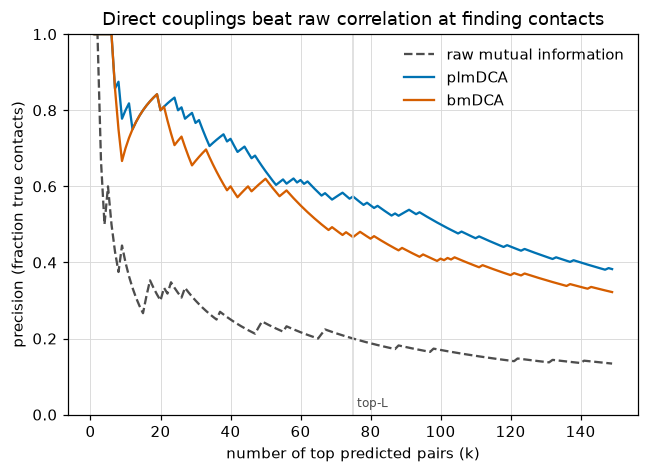

precision of the top-L predictions:  MI 0.20   plm 0.57   bm 0.47


In [11]:
def precision_at(score, contacts, ks):
    L = score.shape[0]
    ii, jj = np.triu_indices(L, k=5)                 # candidate pairs, |i-j| >= 5
    order = np.argsort(score[ii, jj])[::-1]
    hits = contacts[ii, jj][order].astype(float)
    cum = np.cumsum(hits)
    return [cum[k - 1] / k for k in ks]

ks = np.arange(1, 2 * L)
fig, ax = plt.subplots(figsize=(6, 4.4))
for score, lbl, col, ls in [(mi, "raw mutual information", C["data"], "--"),
                            (S_plm_map, "plmDCA", C["plm"], "-"),
                            (S_bm_map, "bmDCA", C["bm"], "-")]:
    ax.plot(ks, precision_at(score, contacts, ks), ls, color=col, label=lbl)
ax.axvline(L, color=C["grid"], lw=1); ax.text(L, 0.02, " top-L", color=C["data"], fontsize=8)
ax.set_xlabel("number of top predicted pairs (k)"); ax.set_ylabel("precision (fraction true contacts)")
ax.set_title("Direct couplings beat raw correlation at finding contacts")
ax.set_ylim(0, 1); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print("precision of the top-L predictions:  "
      + "   ".join(f"{lbl} {precision_at(s, contacts, [L])[0]:.2f}"
                   for s, lbl in [(mi, 'MI'), (S_plm_map, 'plm'), (S_bm_map, 'bm')]))

### 7c. Two-point correlations — the generative test

Here the two methods part ways. A good *generative* model should reproduce the
data's **connected two-point correlations** `c_ij(a,b) = f_ij(a,b) − f_i(a)f_j(b)`.
bmDCA optimises exactly this, so its samples track the data tightly. plmDCA never
constrained it, so its samples systematically **under-reproduce** the correlations —
the points fall off the diagonal. Same couplings-for-contacts, very different as a
generative model.

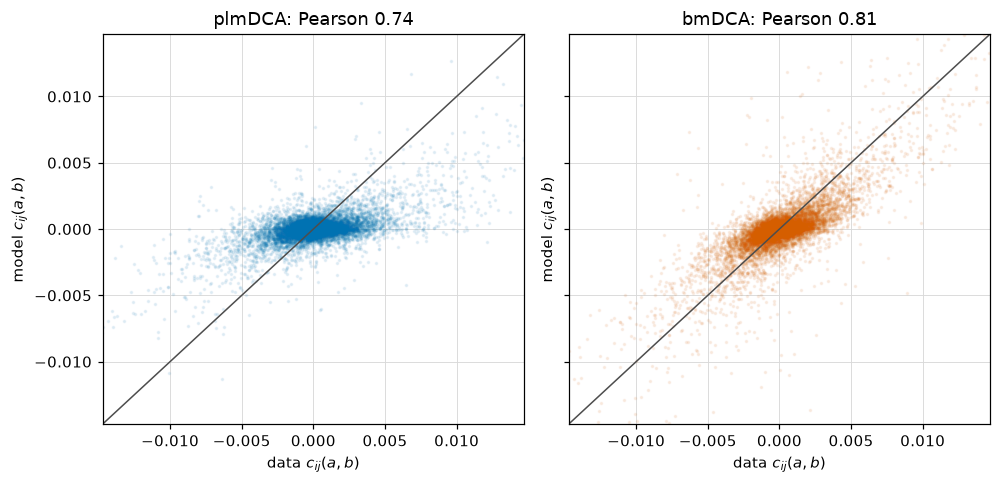

In [12]:
def conn2_vec(f1m, f2m):
    outer = f1m[:, :20, None, None] * f1m[None, None, :, :20]   # f_i(a) f_j(b), layout [i,a,j,b]
    c = f2m[:, :20, :, :20] - outer                            # connected corr, [i,a,j,b]
    return c.transpose(0, 2, 1, 3)[iu].ravel()                 # -> [i,j,a,b], upper triangle

c2_data = conn2_vec(f1_data, f2_data)
sub = np.random.default_rng(0).choice(c2_data.size, 40000, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.5), sharex=True, sharey=True)
lim = np.percentile(np.abs(c2_data), 99.8)
for ax, (f1m, f2m, lbl, col) in zip(axes, [(f1_plm, f2_plm, "plmDCA", C["plm"]),
                                           (f1_bm, f2_bm, "bmDCA", C["bm"])]):
    c2m = conn2_vec(f1m, f2m)
    r = pearsonr(c2_data, c2m)[0]
    ax.scatter(c2_data[sub], c2m[sub], s=2, alpha=0.08, color=col, rasterized=True)
    ax.plot([-lim, lim], [-lim, lim], color=C["data"], lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel("data $c_{ij}(a,b)$"); ax.set_ylabel("model $c_{ij}(a,b)$")
    ax.set_title(f"{lbl}: Pearson {r:.2f}")
plt.tight_layout(); plt.show()

### 7d. Three-point correlations — a stronger, unconstrained test

bmDCA is only *told* to match one- and two-point statistics. Does the model it
learns reproduce **three-point** correlations `c_ijk(a,b,c)` — a genuinely
higher-order property it never optimised? This is the deeper test of a generative
model. We measure connected third-order correlations over a random set of position
triplets. bmDCA largely captures them "for free"; plmDCA does markedly worse.

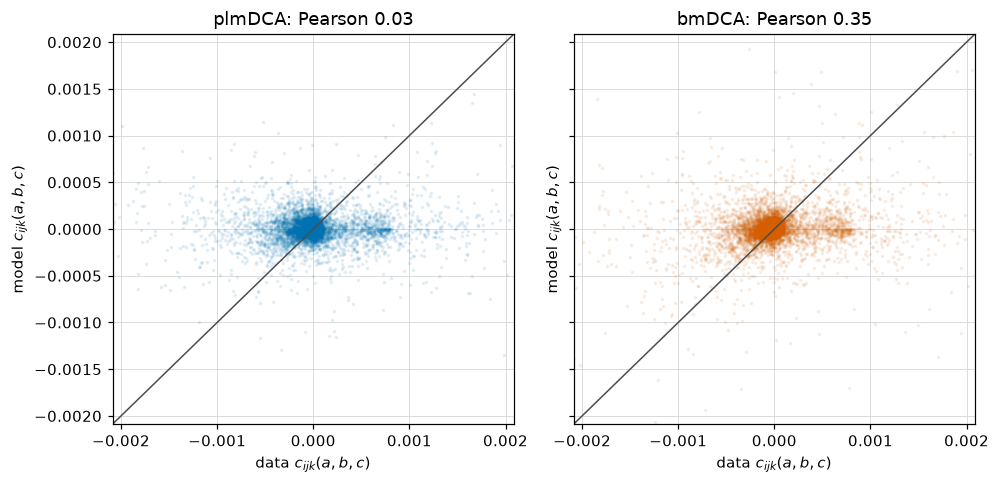

In [13]:
def conn3(Aint, weights, triplets, chunk=64):
    Xf = jax.nn.one_hot(jnp.asarray(Aint), q)[:, :, :20]     # (n, L, 20)
    wj = jnp.ones(Aint.shape[0]) if weights is None else jnp.asarray(weights)
    W = wj.sum()
    f1m = jnp.einsum("n,nia->ia", wj, Xf) / W
    out = []
    for s in range(0, len(triplets), chunk):
        T = jnp.asarray(triplets[s:s + chunk])
        Xi, Xj, Xk = Xf[:, T[:, 0]], Xf[:, T[:, 1]], Xf[:, T[:, 2]]   # (n, c, 20)
        f3 = jnp.einsum("n,nta,ntb,ntc->tabc", wj, Xi, Xj, Xk) / W
        f2ij = jnp.einsum("n,nta,ntb->tab", wj, Xi, Xj) / W
        f2ik = jnp.einsum("n,nta,ntc->tac", wj, Xi, Xk) / W
        f2jk = jnp.einsum("n,ntb,ntc->tbc", wj, Xj, Xk) / W
        fi, fj, fk = f1m[T[:, 0]], f1m[T[:, 1]], f1m[T[:, 2]]         # (c, 20)
        c3 = (f3
              - f2ij[:, :, :, None] * fk[:, None, None, :]
              - f2ik[:, :, None, :] * fj[:, None, :, None]
              - f2jk[:, None, :, :] * fi[:, :, None, None]
              + 2 * fi[:, :, None, None] * fj[:, None, :, None] * fk[:, None, None, :])
        out.append(np.asarray(c3))
    return np.concatenate(out, 0).ravel()

rng = np.random.default_rng(0)
triplets = np.array([rng.choice(L, 3, replace=False) for _ in range(250)])
c3_data = conn3(A, w, triplets)
sub3 = rng.choice(c3_data.size, 40000, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.5), sharex=True, sharey=True)
lim = np.percentile(np.abs(c3_data), 99.8)
for ax, (S, lbl, col) in zip(axes, [(S_plm, "plmDCA", C["plm"]), (S_bm, "bmDCA", C["bm"])]):
    c3m = conn3(S, None, triplets)
    r = pearsonr(c3_data, c3m)[0]
    ax.scatter(c3_data[sub3], c3m[sub3], s=2, alpha=0.08, color=col, rasterized=True)
    ax.plot([-lim, lim], [-lim, lim], color=C["data"], lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel("data $c_{ijk}(a,b,c)$"); ax.set_ylabel("model $c_{ijk}(a,b,c)$")
    ax.set_title(f"{lbl}: Pearson {r:.2f}")
plt.tight_layout(); plt.show()

### 7e. The generative story in one picture

Putting it together: how faithfully does each model reproduce the data's statistics
at each **order** — single-site frequencies (1), connected pair correlations (2),
connected triplet correlations (3)? Both anchor the single-site frequencies. From
there they diverge: **bmDCA stays close at every order**, while **plmDCA falls away**
— it was never asked to match correlations, so its fidelity drops with order. That
gap *is* the difference between a contact predictor and a generative model.

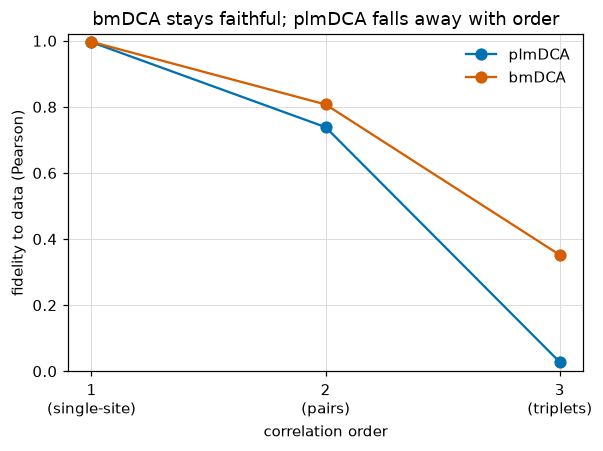

In [14]:
def fidelity(f1m, f2m, S):
    o1 = pearsonr(f1_data[:, :20].ravel(), f1m[:, :20].ravel())[0]
    o2 = pearsonr(c2_data, conn2_vec(f1m, f2m))[0]
    o3 = pearsonr(c3_data, conn3(S, None, triplets))[0]
    return [o1, o2, o3]

fig, ax = plt.subplots(figsize=(5.6, 4.2))
for f1m, f2m, S, lbl, col in [(f1_plm, f2_plm, S_plm, "plmDCA", C["plm"]),
                              (f1_bm, f2_bm, S_bm, "bmDCA", C["bm"])]:
    ax.plot([1, 2, 3], fidelity(f1m, f2m, S), "-o", color=col, label=lbl, ms=7)
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(["1\n(single-site)", "2\n(pairs)", "3\n(triplets)"])
ax.set_xlabel("correlation order"); ax.set_ylabel("fidelity to data (Pearson)")
ax.set_title("bmDCA stays faithful; plmDCA falls away with order")
ax.set_ylim(0, 1.02); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 8. Tradeoffs — when to reach for which

| | **plmDCA** | **bmDCA** |
|---|---|---|
| Objective | pseudo-likelihood (surrogate) | true likelihood (via MCMC) |
| Optimizer | convex, L-BFGS, deterministic | gradient ascent + Gibbs, stochastic |
| Speed | fast (hundreds of iters, one pass/iter) | slow (thousands of steps, MCMC/step) |
| Contact prediction | excellent | excellent |
| Reproduces 2-point stats | no (not constrained) | yes (by construction) |
| Reproduces 3-point stats | partially | largely |
| Generates realistic sequences | no | yes |
| Knobs | regularisation | reg + chains, sweeps, LR schedule |

**Rule of thumb.** If you want a **contact map** or a coupling-strength ranking,
reach for **plmDCA** — it is fast, convex, and just as good at ranking contacts. If
you need a **generative model** — to sample new sequences, score variants by
probability, or study higher-order statistics — pay for **bmDCA**, which actually
reproduces the correlations in the data.

Both were fit here with the same `jaxpotts` energy function, the same reweighted
MSA, and the same zero-sum gauge — differing essentially in the objective (with the
small regularisation-convention differences noted in the code) — which is what let
us compare them apples-to-apples.